# ================================
# Nama      : Fawwaz Rif'at Revista
# Batch     : RMT-039
# Objective : Membuat model Machine Learning untuk memprediksi pembelian yang dilakukan oleh customer
# ================================

# **i. Query SQL**

In [1]:
# Import library untuk query dataset
import pandas as pd
from google.colab import auth
from google.cloud import bigquery
auth.authenticate_user()
print('Authenticated')

project_id = "organic-bivouac-444108-e1"
client = bigquery.Client(project=project_id)

Authenticated


In [2]:
# Load dataset 1
data_1 = client.query('''
SELECT * EXCEPT(fullVisitorId)

FROM
  # features
  (SELECT
    fullVisitorId,
    IFNULL(totals.bounces, 0) AS bounces,
    IFNULL(totals.timeOnSite, 0) AS time_on_site
  FROM
    `data-to-insights.ecommerce.web_analytics`
  WHERE
    totals.newVisits = 1 #gunakan hanya untuk pengunjung baru
    AND date BETWEEN '20160801' AND '20170531') # latih hanya pada 10 bulan pertama
  JOIN
  (SELECT
    fullvisitorid,
    # membuat label atau target
    IF(COUNTIF(totals.transactions > 0 AND totals.newVisits IS NULL) > 0, 1, 0) AS will_buy_on_return_visit
  FROM
      `data-to-insights.ecommerce.web_analytics`
  GROUP BY fullvisitorid)
  USING (fullVisitorId)
  ;
''').to_dataframe()

data_1

,bounces,time_on_site,will_buy_on_return_visit
0,0,733,0
1,1,0,0
2,0,45,0
3,0,951,0
4,0,389,0
...,...,...,...
623996,0,117,0
623997,0,64,0
623998,0,60,0
623999,0,431,0


In [3]:
# Menyimpan dataset_1 dalam format CSV
data_1.to_csv('dataset_1.csv', index=False)

In [4]:
data_2 = client.query('''
WITH all_visitor_stats AS (
SELECT
  fullvisitorid,
  IF(COUNTIF(totals.transactions > 0 AND totals.newVisits IS NULL) > 0, 1, 0) AS will_buy_on_return_visit
  FROM `data-to-insights.ecommerce.web_analytics`
  GROUP BY fullvisitorid
)

SELECT * EXCEPT(unique_session_id) FROM (

  SELECT
      CONCAT(fullvisitorid, CAST(visitId AS STRING)) AS unique_session_id,
      will_buy_on_return_visit,
      MAX(CAST(h.eCommerceAction.action_type AS INT64)) AS latest_ecommerce_progress,

      # perilaku pengguna di situs web
      IFNULL(totals.bounces, 0) AS bounces,
      IFNULL(totals.timeOnSite, 0) AS time_on_site,
      totals.pageviews,

      # informasi dari mana pengunjung itu berasal
      trafficSource.source,
      trafficSource.medium,
      channelGrouping,

      # informasi tentang device yang digunakan user
      device.deviceCategory,

      # informasi tentang geografi user
      IFNULL(geoNetwork.country, "Unknown") AS country

  FROM `data-to-insights.ecommerce.web_analytics`,
    UNNEST(hits) AS h

    JOIN all_visitor_stats USING(fullvisitorid)

  WHERE
    totals.newVisits = 1
    AND date BETWEEN '20160801' AND '20170531'

  GROUP BY
  unique_session_id,
  will_buy_on_return_visit,
  bounces,
  time_on_site,
  totals.pageviews,
  trafficSource.source,
  trafficSource.medium,
  channelGrouping,
  device.deviceCategory,
  country
)

''').to_dataframe()

data_2

,will_buy_on_return_visit,latest_ecommerce_progress,bounces,time_on_site,pageviews,source,medium,channelGrouping,deviceCategory,country
0,0,0,0,54,5,(direct),(none),Direct,desktop,Argentina
1,0,0,0,167,5,(direct),(none),Direct,mobile,India
2,0,0,0,184,5,google,organic,Organic Search,desktop,Ireland
3,0,0,0,141,5,google,organic,Organic Search,desktop,Belarus
4,0,0,0,715,5,google,organic,Organic Search,desktop,Israel
...,...,...,...,...,...,...,...,...,...,...
623935,0,0,0,72,3,youtube.com,referral,Social,desktop,Canada
623936,0,0,0,48,3,youtube.com,referral,Social,mobile,United States
623937,0,0,0,102,2,youtube.com,referral,Social,desktop,Netherlands
623938,0,0,0,40,3,youtube.com,referral,Social,tablet,United States


In [5]:
# Menyimpan dataset_2 dalam format CSV
data_2.to_csv('dataset_2.csv', index=False)

# **ii. Pendahuluan**

## Latar Belakang

Marketing harus dilaksanakan dengan tepat sasaran karena biaya yang dikeluarkan juga tidak sedikit. Agar marketing yang dilakukan tepat sasaran, maka Divisi/Tim Marketing di suatu perusahaan harus mengetahui jenis promosi/campaign yang tepat pada tiap kelompok yang berbeda karena tiap kelompok memiliki ciri khas/keunikannya masing-masing yang tidak dimiliki oleh kelompok lainnya. Oleh karena itu, agar promosi/campaign yang dilakukan dapat tepat sasaran, maka Tim Marketing harus mengetahui perbedaan-perbedaan yang dimiliki oleh tiap kelompok maupun individu.

## Problem Statement

Suatu perusahaan sering mengalami kerugian pada tiap promosi/campaign yang dilakukan karena promosi yang dilakukan tidak tepat sasaran. Oleh karena itu, Divisi/Tim Marketing perusahaan ingin mengetahui faktor-faktor apa saja yang memengaruhi seorang customer untuk melakukan pembelian atau tidak.

## Tujuan/Objective

1. Mengetahui faktor-faktor yang memengaruhi keputusan pembelian barang dari customer
2. Membuat model Machine Learning yang dapat memprediksi keputusan pembelian barang
3. Memberikan saran kepada Tim Marketing terkait campaign/promosi yang ingin dilakukan

## *SMART Framework*

1. S : Meningkatkan pendapatan melalui promosi yang tepat
2. M : Meningkatkan 50% pendapatan
3. A : Berdasarkan data yang ada dan dengan uji statistik yang dilakukan, hal tersebut dapat dicapai
4. R : Mengetahui faktor-faktor yang berpengaruh terhadap keputusan pembelian customer dapat memberikan insight kepada Tim Marketing untuk menerapkan promosi yang tepat
5. T : Menyelesaikan analisis dalam waktu 1 hari dan Meningkatkan 50% pendapatan dalam waktu 1 tahun

# **iii. Import Libraries**

In [6]:
# Import Libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from scipy.stats import f_oneway
from scipy.stats import chisquare
from feature_engine.outliers import Winsorizer
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, f1_score
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, learning_curve
from sklearn.tree import DecisionTreeClassifier as DecisionTree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

# **iv. Data Loading**

In [7]:
# Load datset 1
data_1 = pd.read_csv('dataset_1.csv')

In [8]:
data_1 = data_1.rename(columns={'will_buy_on_return_visit': 'buying'})
data_1

,bounces,time_on_site,buying
0,0,733,0
1,1,0,0
2,0,45,0
3,0,951,0
4,0,389,0
...,...,...,...
623996,0,117,0
623997,0,64,0
623998,0,60,0
623999,0,431,0


In [9]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624001 entries, 0 to 624000
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   bounces       624001 non-null  int64
 1   time_on_site  624001 non-null  int64
 2   buying        624001 non-null  int64
dtypes: int64(3)
memory usage: 14.3 MB


In [10]:
# Mengubah tipe data
data_1['bounces'] = data_1['bounces'].astype('str')
data_1['buying'] = data_1['buying'].astype('str')

In [11]:
# Load datset 2
data_2 = pd.read_csv('dataset_2.csv')

In [12]:
data_2 = data_2.rename(columns={'will_buy_on_return_visit': 'buying'})

In [13]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 623940 entries, 0 to 623939
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   buying                     623940 non-null  int64  
 1   latest_ecommerce_progress  623940 non-null  int64  
 2   bounces                    623940 non-null  int64  
 3   time_on_site               623940 non-null  int64  
 4   pageviews                  623926 non-null  float64
 5   source                     623940 non-null  object 
 6   medium                     623940 non-null  object 
 7   channelGrouping            623940 non-null  object 
 8   deviceCategory             623940 non-null  object 
 9   country                    623940 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 47.6+ MB


# **v. Exploratory Data Analysis (EDA)**

## Soal No.1

In [14]:
# Buat variabel baru berisi 3 fitur dan 1 label
X = data_2[['bounces', 'time_on_site', 'pageviews', 'buying']]

In [15]:
# Menampilkan jumlah unique values
X.nunique()

,0
bounces,2
time_on_site,3619
pageviews,180
buying,2


In [16]:
# Menampilkan
X.isna().sum()

,0
bounces,0
time_on_site,0
pageviews,14
buying,0


In [17]:
# Imputasi missing value dengan nilai minimal
X['pageviews']= X['pageviews'].fillna(1)

<ipython-input-17-e0179b550933>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['pageviews']= X['pageviews'].fillna(1)


In [18]:
# Uji Korelasi bounces dengan buying menggunakan Uji Korelasi Chi Square
contingency_table = pd.crosstab(X['bounces'], X['buying'])
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print('Nilai Chi Square Statistics  :', chi2_stat)
print('Nilai P-Value                :', p_value)

Nilai Chi Square Statistics  : 6447.365066535414
Nilai P-Value                : 0.0


Uji korelasi Chi Square dipilih karena tipe data pada fitur bounces merupakan data kategorikal (nominal) dan tipe data label buying juga merupakan data ketegorikal, sehingga uji Chi Square akan lebih cocok untuk digunakan dalam kasus data ini.

In [19]:
# Uji Distribusi Normalitas
print('Nilai Normalitas Skewness time_on_site : ', X['time_on_site'].skew())
print('Nilai Normalitas Skewness pageviews    : ', X['pageviews'].skew())

Nilai Normalitas Skewness time_on_site :  6.095614303604387
Nilai Normalitas Skewness pageviews    :  8.609187831542732


Berdasarkan hasil uji normalitas tersebut, didapatkan hasil uji Skewness time_on_site dan pageviews adalah 6,09 dan 8,6, yang artinya nilai tersebur berada diluar range -0,5 - 0,5, sehingga dapat ditarik kesimpulan bahwa distribusinya adalah highly skewed. Fitur yang tidak berdistribusi normal/skewed harus dilakukan capping dengan metode Tukey's Rule

Uji ANOVA digunakna untuk mengetahui pengaruh/hubungan fitur time_on_site dan pageviews terhadap label buying. Uji ini dipilih karena Uji ANOVA dapat digunakan untuk uji pada data dengan fitur dan label yang berbeda tipe datanya, termasuk pada data di kasus ini.

In [20]:
# Uji ANOVA fitur time_on_site
time = [X['time_on_site'][X['buying'] == category] for category in X['buying'].unique()]
time_anova = f_oneway(*time)
print("F-statistic  :", time_anova.statistic)
print("P-value      :", time_anova.pvalue)

F-statistic  : 9404.215264454704
P-value      : 0.0


In [21]:
# Uji ANOVA fitur pageviews
page = [X['pageviews'][X['buying'] == category] for category in X['buying'].unique()]
page_anova = f_oneway(*page)
print("F-statistic  :", page_anova.statistic)
print("P-value      :", page_anova.pvalue)

F-statistic  : 15223.676091363888
P-value      : 0.0


## Soal No.2

Untuk mengetahui peluang/potensi pembelian berdasarakan device dapat diketahui berdasarkan persentase value 0 dan 1 pada label/fitur buying. Semakin besar persentasenya maka akan semakin besar pula peluang customer untuk membeli produk.

In [22]:
# Membuat dataset device dan buying berdasarkan negara Canada
device_data = data_2[data_2['country']=='Canada'][[ 'deviceCategory', 'buying']]
device_data

,deviceCategory,buying
172,desktop,0
182,desktop,0
229,desktop,0
249,desktop,0
298,mobile,0
...,...,...
623791,desktop,0
623822,desktop,0
623872,desktop,0
623901,desktop,0


In [23]:
# Menampilkan sebaran data tiap jenis device
result = device_data.groupby('deviceCategory')['buying'].value_counts().unstack(fill_value=0)
result

buying,0,1
deviceCategory,,
desktop,11031,189
mobile,3979,11
tablet,899,1


In [24]:
# Persentase pembelian berdasarkan device
print('Persentase pembelian Desktop = ', 189/11425*100,'%')
print('Persentase pembelian Mobile  = ', 11/3990*100,'%')
print('Persentase pembelian Desktop = ', 1/900*100,'%')

Persentase pembelian Desktop =  1.6542669584245075 %
Persentase pembelian Mobile  =  0.2756892230576441 %
Persentase pembelian Desktop =  0.1111111111111111 %


Berdasarkan hasil perhitungan persentase, diketahui bahwa device Desktop adalah jenis Device dengan pengguna terbanyak dan juga dengan persentase untuk melakukan pembelian terbesar.

# **vi. Modelling 1**

## i. Feature Engineering

In [25]:
# Menampilkan dataset
data_1

,bounces,time_on_site,buying
0,0,733,0
1,1,0,0
2,0,45,0
3,0,951,0
4,0,389,0
...,...,...,...
623996,0,117,0
623997,0,64,0
623998,0,60,0
623999,0,431,0


In [26]:
# Menampilkan jumlah missing value
data_1.isna().sum()

,0
bounces,0
time_on_site,0
buying,0


Tidak ada missing value pada data di atas, sehingga tidak perlu dilakukan imputasi

In [27]:
# Split fitur dan label
X = data_1.drop(columns=['buying'])
y = data_1['buying']

In [28]:
# Split data train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 20)
print('Train Size: ', X_train.shape)
print('Test Size: ', X_test.shape)

Train Size:  (499200, 2)
Test Size:  (124801, 2)


In [29]:
# Split data train imbalanced dan test
X_train_imbalanced, X_test, y_train_imbalanced, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
y_train_imbalanced.value_counts()

,count
buying,
0,491503
1,7697


In [30]:
# Uji Distribusi Normalitas
print('Nilai Normalitas Skewness time_on_site : ', X['time_on_site'].skew())

Nilai Normalitas Skewness time_on_site :  6.095895402508084


Berdasarkan hasil uji distribusi normalitasnya, didapathasil hasil Uji Skewnwss 6,09 dimana nilai tersebut diluar range -0,5 - 0,5, sehingga didapatkan kesimpulan bahwa data tersebut highly skewed. Untuk mencari outlier pada data highly skewed digunakan metode Tukey's rule yang menggunakan nilai IQR.

In [31]:
# Handling outlier
skew = ['time_on_site']
winsorizer_1 = Winsorizer(capping_method='iqr',
                        tail='both',
                        fold=3,
                        variables=skew,
                        missing_values='ignore')

X_train_capped = winsorizer_1.fit_transform(X_train)
X_test_capped = winsorizer_1.transform(X_test)

In [32]:
# Encoding Label
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [33]:
# Balancing data menggunakan SMOTENC
smote = SMOTENC(categorical_features = [0], sampling_strategy='minority', k_neighbors=5, random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_imbalanced, y_train_imbalanced)
y_train_balanced.value_counts()

,count
buying,
0,491503
1,491503


In [34]:
# Menampilkan dataset
data_1

,bounces,time_on_site,buying
0,0,733,0
1,1,0,0
2,0,45,0
3,0,951,0
4,0,389,0
...,...,...,...
623996,0,117,0
623997,0,64,0
623998,0,60,0
623999,0,431,0


In [35]:
# Menampilkan jumlah missing value
data_1.isna().sum()

,0
bounces,0
time_on_site,0
buying,0


Tidak ada missing value pada data di atas, sehingga tidak perlu dilakukan imputasi

In [36]:
# Split fitur dan label
X = data_1.drop(columns=['buying'])
y = data_1['buying']

In [37]:
# Split data train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 20)
print('Train Size: ', X_train.shape)
print('Test Size: ', X_test.shape)

Train Size:  (499200, 2)
Test Size:  (124801, 2)


In [38]:
# Split data train imbalanced dan test
X_train_imbalanced, X_test, y_train_imbalanced, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
y_train_imbalanced.value_counts()

,count
buying,
0,491503
1,7697


In [39]:
# Uji Distribusi Normalitas
print('Nilai Normalitas Skewness time_on_site : ', X['time_on_site'].skew())

Nilai Normalitas Skewness time_on_site :  6.095895402508084


Berdasarkan hasil uji distribusi normalitasnya, didapathasil hasil Uji Skewnwss 6,09 dimana nilai tersebut diluar range -0,5 - 0,5, sehingga didapatkan kesimpulan bahwa data tersebut highly skewed. Untuk mencari outlier pada data highly skewed digunakan metode Tukey's rule yang menggunakan nilai IQR.

In [40]:
# Handling outlier
skew = ['time_on_site']
winsorizer_1 = Winsorizer(capping_method='iqr',
                        tail='both',
                        fold=3,
                        variables=skew,
                        missing_values='ignore')

X_train_capped = winsorizer_1.fit_transform(X_train)
X_test_capped = winsorizer_1.transform(X_test)

In [41]:
# Encoding Label
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [42]:
# Balancing data menggunakan SMOTENC
smote = SMOTENC(categorical_features = [0], sampling_strategy='minority', k_neighbors=5, random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_imbalanced, y_train_imbalanced)
y_train_balanced.value_counts()

,count
buying,
0,491503
1,491503


## ii. Model Definition

Model yang akan digunakan untuk melakukan prediksi fitur 'buying' pada dataset ini adalah Regresi Logistic. Pemilihan Regresi Logistik karena output yang dihasilkan adalah data yang berbentuk biner, sehingga Regresi Logistik cocok untuk digunakan. Selain itu, Regresi Logistik tidak memerlukan pemenuhan uji asumsi klasik dan tidak memerlukan hubungan yang linear.

## iii. Model Training

### Regresi Logistik

In [43]:
# Memisahkah kolom numerikal dan kategorikal
num_columns = X_train_balanced.select_dtypes(include=np.number).columns.tolist()
cat_columns = X_train_balanced.select_dtypes(include=['object']).columns.tolist()

print('Numerical Columns : ', num_columns)
print('Categorical Columns : ', cat_columns)

Numerical Columns :  ['time_on_site']
Categorical Columns :  ['bounces']


In [44]:
# Membuat pipeline berdasarkan tipe data (numerik dan kategorik)
num_pipeline = make_pipeline(MinMaxScaler())

cat_pipeline = make_pipeline(OrdinalEncoder())

preprocessing_pipeline = ColumnTransformer([
    ('pipe_num', num_pipeline, num_columns),
    ('pipe_cat', cat_pipeline, cat_columns)
])

clf = make_pipeline(preprocessing_pipeline, LogisticRegression())
clf.fit(X_train_balanced, y_train_balanced)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipe_num',
                                                  Pipeline(steps=[('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['time_on_site']),
                                                 ('pipe_cat',
                                                  Pipeline(steps=[('ordinalencoder',
                                                                   OrdinalEncoder())]),
                                                  ['bounces'])])),
                ('logisticregression', LogisticRegression())])

MinMaxScaler dipilih karena distribusi data pada fitur time_on_site tidak normal, sehingga MinMaxScaler dipilih karena dapat diterpkan pada data yang tidak berdistribusi normal.

## iv. Model Evaluation

Model Evaluation yang akan digunakan adalah F1-score karena nilai False Negative (FN) dan False Positive (FP) sama-sama penting pada model ini, sehingga digunakanlah nilai accuracy F1-score.

In [45]:
# Model evaluasi dengan Classification Report

y_pred_train = clf.predict(X_train_balanced)
y_pred_test = clf.predict(X_test)
y_test = y_test.astype(int)
y_pred_test = y_pred_test.astype(int)


print('Train')
print(classification_report(y_train_balanced, y_pred_train))
print('')

print('Test')
print(classification_report(y_test, y_pred_test))

Train
              precision    recall  f1-score   support

           0       0.84      0.51      0.63    491503
           1       0.65      0.91      0.76    491503

    accuracy                           0.71    983006
   macro avg       0.75      0.71      0.69    983006
weighted avg       0.75      0.71      0.69    983006


Test
              precision    recall  f1-score   support

           0       1.00      0.50      0.67    122851
           1       0.03      0.90      0.05      1950

    accuracy                           0.51    124801
   macro avg       0.51      0.70      0.36    124801
weighted avg       0.98      0.51      0.66    124801



Berdasarkan hasil evaluasi model dengan metode F1-Score, didapatkan hasil accuracy train 0,71 (71%) dan test 0,51 (51%). Nilai train yang didapatkan adalah 71%, sehingga model dapat dikatakan underfit karena memiliki accuracy <80%. Oleh karena itu berdasarkan hasil evalusi model classification, maka model machine learning dengan fitur bounces, time_on_site, dan pageviews tidak dapat digunakan untuk memprediksi keputusan pembelian customer dengan baik.

In [46]:
# # Model evaluasi dengan ROC_AUC
y_pred_test = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_pred_test)
print("AUC:", roc_auc)

AUC: 0.7779905781216312


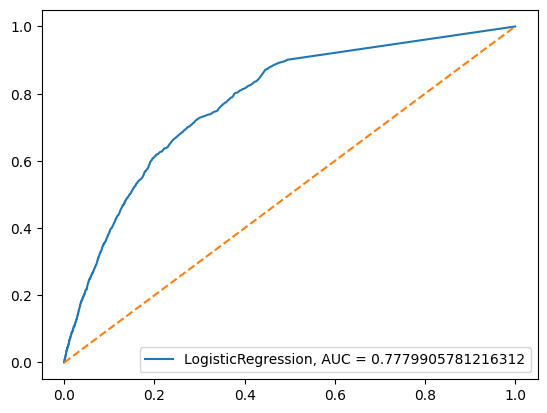

In [47]:
# Membuat plot ROC_AUC
plt.figure(0).clf()
plt.plot(fpr, tpr, label='LogisticRegression, AUC = ' + str(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend(loc=0)

Berdasarkan hasil evaluasi model dengan metode ROC_AUC didapatkan score AUC 0,77, sehingga termasuk dalam kategori Decent.

# **vii. Modelling 2**

## i. Feature Engineering

In [48]:
# Menampilkan dataset
data_2

,buying,latest_ecommerce_progress,bounces,time_on_site,pageviews,source,medium,channelGrouping,deviceCategory,country
0,0,0,0,54,5.0,(direct),(none),Direct,desktop,Argentina
1,0,0,0,167,5.0,(direct),(none),Direct,mobile,India
2,0,0,0,184,5.0,google,organic,Organic Search,desktop,Ireland
3,0,0,0,141,5.0,google,organic,Organic Search,desktop,Belarus
4,0,0,0,715,5.0,google,organic,Organic Search,desktop,Israel
...,...,...,...,...,...,...,...,...,...,...
623935,0,0,0,72,3.0,youtube.com,referral,Social,desktop,Canada
623936,0,0,0,48,3.0,youtube.com,referral,Social,mobile,United States
623937,0,0,0,102,2.0,youtube.com,referral,Social,desktop,Netherlands
623938,0,0,0,40,3.0,youtube.com,referral,Social,tablet,United States


In [49]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 623940 entries, 0 to 623939
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   buying                     623940 non-null  int64  
 1   latest_ecommerce_progress  623940 non-null  int64  
 2   bounces                    623940 non-null  int64  
 3   time_on_site               623940 non-null  int64  
 4   pageviews                  623926 non-null  float64
 5   source                     623940 non-null  object 
 6   medium                     623940 non-null  object 
 7   channelGrouping            623940 non-null  object 
 8   deviceCategory             623940 non-null  object 
 9   country                    623940 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 47.6+ MB


In [50]:
# Mengubah tipe data yang tidak sesuai
data_2['bounces'] = data_2['bounces'].astype(str)
data_2['latest_ecommerce_progress'] = data_2['latest_ecommerce_progress'].astype(str)

In [51]:
data_2['medium'] = data_2['medium'].replace({'(none)': None})

In [52]:
# Menampilkan jumlah missing value
data_2.isna().sum()

,0
buying,0
latest_ecommerce_progress,0
bounces,0
time_on_site,0
pageviews,14
source,0
medium,98913
channelGrouping,0
deviceCategory,0
country,0


In [53]:
data_2.nunique()

,0
buying,2
latest_ecommerce_progress,7
bounces,2
time_on_site,3619
pageviews,180
source,294
medium,6
channelGrouping,8
deviceCategory,3
country,218


In [54]:
# Imputasi missing value
data_2['pageviews']= data_2['pageviews'].fillna(1)
# Imputassi fitur medium dengan modus
modus_medium = data_2['medium'].mode()[0]
data_2['medium'] = data_2['medium'].fillna(modus_medium)

Missing value diisi dengan seminimal-minimalny seseorang melihat 1 halaman dari website.

In [55]:
# Split fitur dan label
X = data_2.drop(columns=['buying', 'source', 'country'])
y = data_2['buying']

In [56]:
# Split data train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 20)
print('Train Size: ', X_train.shape)
print('Test Size: ', X_test.shape)

Train Size:  (499152, 7)
Test Size:  (124788, 7)


In [57]:
# Uji Distribusi Normalitas
print('Nilai Normalitas Skewness time_on_site : ', X['time_on_site'].skew())
print('Nilai Normalitas Skewness pageviews    : ', X['pageviews'].skew())

Nilai Normalitas Skewness time_on_site :  6.095614303604387
Nilai Normalitas Skewness pageviews    :  8.609187831542732


Uji normalitas hanya dilakukan pada data numerikal. Berdasarkan hasil uji distribusi normalitasnya, didapathasil hasil Uji Skewnwss 6,09 dimana nilai tersebut diluar range -0,5 - 0,5, sehingga didapatkan kesimpulan bahwa data tersebut highly skewed. Untuk mencari outlier pada data highly skewed digunakan metode Tukey's rule yang menggunakan nilai IQR.

In [58]:
# Handling outlier dan Capping
skew = ['time_on_site', 'pageviews']
winsorizer_2 = Winsorizer(capping_method='iqr',
                        tail='both',
                        fold=3,
                        variables=skew,
                        missing_values='ignore')

X_train_capped = winsorizer_2.fit_transform(X_train)
X_test_capped = winsorizer_2.transform(X_test)

In [59]:
# Encoding Label
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

## ii. Model Definition

## iii. Model Training

In [60]:
data_2

,buying,latest_ecommerce_progress,bounces,time_on_site,pageviews,source,medium,channelGrouping,deviceCategory,country
0,0,0,0,54,5.0,(direct),referral,Direct,desktop,Argentina
1,0,0,0,167,5.0,(direct),referral,Direct,mobile,India
2,0,0,0,184,5.0,google,organic,Organic Search,desktop,Ireland
3,0,0,0,141,5.0,google,organic,Organic Search,desktop,Belarus
4,0,0,0,715,5.0,google,organic,Organic Search,desktop,Israel
...,...,...,...,...,...,...,...,...,...,...
623935,0,0,0,72,3.0,youtube.com,referral,Social,desktop,Canada
623936,0,0,0,48,3.0,youtube.com,referral,Social,mobile,United States
623937,0,0,0,102,2.0,youtube.com,referral,Social,desktop,Netherlands
623938,0,0,0,40,3.0,youtube.com,referral,Social,tablet,United States


In [61]:
data_2.columns

Index(['buying', 'latest_ecommerce_progress', 'bounces', 'time_on_site',
       'pageviews', 'source', 'medium', 'channelGrouping', 'deviceCategory',
       'country'],
      dtype='object')

In [62]:
# Memisahkah kolom numerikal dan kategorikal
num_columns = X_train.select_dtypes(include=np.number).columns.tolist()
cat_columns = X_train.select_dtypes(include=['object']).columns.tolist()

print('Numerical Columns : ', num_columns)
print('Categorical Columns : ', cat_columns)

Numerical Columns :  ['time_on_site', 'pageviews']
Categorical Columns :  ['latest_ecommerce_progress', 'bounces', 'medium', 'channelGrouping', 'deviceCategory']


In [63]:
# Membuat pipeline berdasarkan tipe data (numerik dan kategorik)
num_pipeline = make_pipeline(MinMaxScaler())

ordinal_pipeline = make_pipeline(OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))

preprocessing_pipeline = ColumnTransformer([
    ('pipe_num', num_pipeline, num_columns),
    ('pipe_cat', cat_pipeline, cat_columns)
])

clf = make_pipeline(preprocessing_pipeline, LogisticRegression())
clf.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipe_num',
                                                  Pipeline(steps=[('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['time_on_site',
                                                   'pageviews']),
                                                 ('pipe_cat',
                                                  Pipeline(steps=[('ordinalencoder',
                                                                   OrdinalEncoder())]),
                                                  ['latest_ecommerce_progress',
                                                   'bounces', 'medium',
                                                   'channelGrouping',
                                                   'deviceCategory'])])),
                ('logisticregression', LogisticRegression())])

## iv. Model Evaluation

In [64]:
data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 623940 entries, 0 to 623939
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   buying                     623940 non-null  int64  
 1   latest_ecommerce_progress  623940 non-null  object 
 2   bounces                    623940 non-null  object 
 3   time_on_site               623940 non-null  int64  
 4   pageviews                  623940 non-null  float64
 5   source                     623940 non-null  object 
 6   medium                     623940 non-null  object 
 7   channelGrouping            623940 non-null  object 
 8   deviceCategory             623940 non-null  object 
 9   country                    623940 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 47.6+ MB


In [65]:
# Model evaluasi dengan Classification Report

y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)


print('Train')
print(classification_report(y_train, y_pred_train))
print('')

print('Test')
print(classification_report(y_test, y_pred_test))

Train


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.98      1.00      0.99    491472
           1       0.00      0.00      0.00      7680

    accuracy                           0.98    499152
   macro avg       0.49      0.50      0.50    499152
weighted avg       0.97      0.98      0.98    499152


Test
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    122821
           1       0.00      0.00      0.00      1967

    accuracy                           0.98    124788
   macro avg       0.49      0.50      0.50    124788
weighted avg       0.97      0.98      0.98    124788



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Berdasarkan hasil F1-score, didapatkan hasil uji dengan kategori Goodfit karena nilai accuracy >80% dan gap train-test <5%, sehingga model disimpulkan Goodfit.

In [66]:
# # Model evaluasi dengan ROC_AUC
y_pred_test = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_pred_test)
print("AUC:", roc_auc)

AUC: 0.8740333553477271


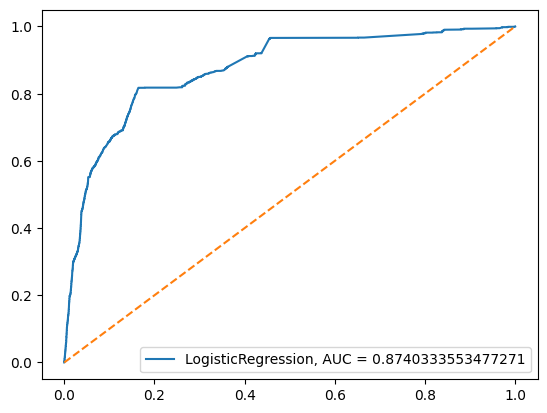

In [67]:
# Membuat plot ROC_AUC
plt.figure(0).clf()
plt.plot(fpr, tpr, label='LogisticRegression, AUC = ' + str(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend(loc=0)

Nilai AUC yang didapatkan adalah 0,87 yang terletak pada range 0,8 - 0,9, sehingga berdasarkan hasil tersebut dapat disimpulkan bahwa model termasuk dalam kategori Fair dimana lebih tinggi dibanding dengan model sebelumnya.

# **viii. Model Saving**

In [68]:
import pickle
import json

with open('list_num_cols.txt', 'w') as file_1:
  json.dump(num_columns, file_1)

with open('list_cat_cols.txt', 'w') as file_2:
  json.dump(cat_columns, file_2)

with open('scaler.pkl', 'wb') as file_3:
  pickle.dump(MinMaxScaler(), file_3)

with open('encoder.pkl', 'wb') as file_4:
  pickle.dump(OrdinalEncoder(), file_4)

with open('model_log_reg.pkl', 'wb') as file_5:
  pickle.dump(LogisticRegression(), file_5)

# **ix. Kesimpulan**

Berdasarkan hasil uji yang telah dilakukan, maka model Machine Learning yang akan digunakan adalah model ke-2 dimana pada model tersebut fitur yang digunakan untuk memprediksi keputusan pembelian customer lebih banyak dan prediksi yang diberikanpun semakin akur (lebih akurat dari model 1). Oleh karena itu model ke-2 dipilih untuk digunakan sebagai estimator.